# IN4080: obligatory assignment 2 (Autumn 2026)

Mandatory assignment 2 consists of three parts. In Part 1, you will experiment with a greedy sequence labeling model and investigate the impact of different feature types on **part-of-speech tagging** performance (9 points + 2 optional bonus points). In Part 2, you will evaluate the best model on a different task, **named entity recognition** (5 points). In Part 3, you will return to the **text classification task** and implement a simple feed-forward neural network for it (6 points).

You should answer all three parts. You are required to get at least 12/20 points to pass. The most important is that you try to answer each question (possibly with some mistakes), to help you gain a better and more concrete understanding of the topics covered during the lectures. In the first part, there are also bonus questions for those of you who would like to deepen their understanding of the topics covered by this assignment.

- We assume that you have read and are familiar with IFI’s requirements and guidelines for mandatory assignments, see [here](https://www.uio.no/english/studies/examinations/compulsory-activities/mn-ifi-mandatory.html) and [here](https://www.uio.no/english/studies/examinations/compulsory-activities/mn-ifi-guidelines.html).
- This is an individual assignment. You should not deliver joint submissions.
- You may redeliver in Devilry before the deadline (__Friday, October 2 at 23:59__), but include all files in the last delivery.
- Only the last delivery will be read! If you deliver more than one file, put them into a zip-archive. You don't have to include in your delivery the files already provided for this assignment.
- Name your submission _your\_username\_in4080\_mandatory\_2_
- You can work on this assignment either on the IFI machines or on your own computer.

*The preferred format for the assignment is a completed version of this Jupyter notebook*, containing both your code and explanations about the steps you followed. We want to stress that simply submitting code is __not__ by itself sufficient to complete the assignment - we expect the notebook to also contain explanations of what you have implemented, along with motivations for the choices you made along the way. Preferably use whole sentences, and mathematical formulas if necessary. Explaining in your own words (using concepts we have covered through in the lectures) what you have done and reflecting on your solution is an important part of the learning process - take it seriously!

Regarding the use of LLMs (ChatGPT or similar): you are allowed to use them as 'sparring partner', for instance to clarify something you have not understood. However, you are __not__ allowed to use them to generate solutions (either in part or in full) to the assignment tasks. If you are using code editors such as VS Code, you should make sure that code completion plugins such as Copilot are disabled when working on the assignment.

In this assignment, we'll use the following Python modules: `scikit-learn, pyconll, matplotlib, sentence_transformers`. Make sure you have installed them.

## Part 1 – Greedy logistic regression taggers and feature engineering

In the lecture, we have discussed Matthew Honnibal's proposal of a discriminative sequence labelling model with greedy decoding. He argued that an extended set of features is more helpful for tagging than exact (Viterbi) decoding. Therefore, we skip HMMs and the Viterbi algorithm here and focus on models based on logistic regression.

Scikit-learn doesn't contain implementations of sequence labeling models. Therefore, we provide you with some basic code. The code below defines a `GreedyTagger` with a `fit()` function for training and a `predict()` function for prediction/testing. By default, it uses a standard Scikit-learn logistic regression classifier under the hood, which takes a feature vector for a word (and its context) as input and provides the most likely class label as output.

Your task in this part will mainly consist in defining how a word (and its context) is converted to a feature vector.

In [37]:
import numpy as np
import sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction import DictVectorizer


class GreedyTagger:
    """
    Tagger based on logistic regression or any other classification algorithm supported by Scikit-Learn.
    """

    def __init__(
        self,
        feature_function,
        classifier=LogisticRegression(),
    ):
        """
        Creates a GreedyTagger object.

        Args:
            feature_function: A function that transforms the input sequence and the index of the current word into a set of key-value pairs.
            classifier: A Scikit-Learn classifier instance.
        """
        self.features = feature_function
        self.classifier = classifier
        self.vectorizer = DictVectorizer()
        self.label_ids = {}  # mapping from labels to numeric label ids
        self.id_labels = {}  # mapping from numeric label ids to labels

    def fit(self, dataset_X, dataset_Y):
        """
        Trains the tagger. Creates a list of inputs (feature vectors of individual words) and a list of labels (numeric ids) and calls the `fit` function of the base classifier on these lists.

        Args:
            dataset_X: The input training data, formatted as a list of lists. Each list item represents a sentence and corresponds to a list of tokens.
            dataset_Y: The training data labels, formatted as a list of lists. Each list item represents a sentence and corresponds to a list of labels (e.g. POS-tags or BIO-tags).
        """
        flattened_dataset_X = []  # a flat list of training instances
        flattened_dataset_Y = []  # a flat list of label ids for the training instances
        for sentence_X, sentence_Y in zip(dataset_X, dataset_Y):
            # sentence_X is a list of words
            # sentence_Y is a list of labels, one for each word of the sentence
            history = []
            for i, (x, y) in enumerate(zip(sentence_X, sentence_Y)):
                feature_dict = self.features(sentence_X, i, history)
                flattened_dataset_X.append(feature_dict)
                if y not in self.label_ids:
                    self.label_ids[y] = len(self.label_ids)
                flattened_dataset_Y.append(self.label_ids[y])
                history.append(y)
        transformed_dataset_X = self.vectorizer.fit_transform(flattened_dataset_X) # Convert the sparse matrix indices to int32 to avoid compatibility issues
        transformed_dataset_X.indices = transformed_dataset_X.indices.astype(np.int32)
        transformed_dataset_X.indptr = transformed_dataset_X.indptr.astype(np.int32)
        transformed_dataset_Y = np.array(flattened_dataset_Y)
        self.id_labels = {self.label_ids[label]: label for label in self.label_ids}
        self.classifier.fit(transformed_dataset_X, transformed_dataset_Y)
        return self

    def predict(self, dataset_X):
        """
        Predicts the labels for the input data, sentence by sentence.

        Args:
            dataset_X: The input training data, formatted as a list of lists. Each list item represents a sentence and corresponds to a list of tokens.

        Returns:
            list: The predicted labels, in the same format as dataset_X (list of lists).
        """
        predictions = []
        for sentence_X in dataset_X:
            flattened_sentence_X = []
            history = []
            for i, word in enumerate(sentence_X):
                feature_dict = self.features(sentence_X, i, history)
                flattened_sentence_X.append(feature_dict)
            transformed_sentence_X = self.vectorizer.transform(flattened_sentence_X)
            predicted_sentence_Y = self.classifier.predict(transformed_sentence_X)
            predicted_labels_Y = [self.id_labels[y] for y in predicted_sentence_Y]
            predictions.append(predicted_labels_Y)
        return predictions

When instantiating this class, you need to provide a so-called *feature function* that defines how the feature vector is created. In the provided implementation, this is done in two steps:
1. The feature function creates a feature dictionary. Each key of the dictionary defines a one-hot vector, and the value determines which value of the vector will be set to one. For example, the feature dictionary `{"curr_word": "love", "prev_word": "I", "next_word": "fish"}` defines three one-hot vectors, which together represent the word `love` in the sequence `I love fish`. The keys can be chosen freely.
2. The `DictVectorizer` class of Scikit-Learn will convert the feature dictionary to actual one-hot vectors and concatenate them into a single vector. This step is already taken care of in the `fit()` function.

A basic feature function that only uses the current word could look like this (we will use the parameter `history` later, but don't worry about it now):

In [38]:
def basic_features(sentence, i, history):
    features = {"curr_word": sentence[i]}
    return features

The `predict()` function only returns the predicted labels, it doesn't compare them to the ground truth. Here is another function that computes accuracy for the predictions of a dataset. However, the function is incomplete -- it only uses the first sentence of the dataset.

**Task 1.1** (1 point): Modify the function to take into account all sentences of the dataset. The easiest way to achieve this is to flatten a list of lists into a single list, so you'll only have to call the `accuracy_score` function once.

In [39]:
def tagging_accuracy(dataset_Y_true, dataset_Y_pred):


    y_true =[]
    y_pred = []
    for sentence in dataset_Y_true:
        y_true.extend(sentence)
    for sentence in dataset_Y_pred:
        y_pred.extend(sentence)
    
    acc = sklearn.metrics.accuracy_score(y_true, y_pred)
    return acc

Finally, we need some actual data to work with. We provide you with part-of-speech annotated data for Norwegian Bokmål taken from (https://universaldependencies.org/).

There are two ways of loading the data here:

1. You can use the `pyconll` library


2. You can use our preprocessed `.conllu` files, which are saved as `.json` files

In [40]:
import json


def load_data_from_json(filename):
    with open(filename, "r", encoding="utf-8") as f:
        data = json.load(f)
    X, Y = [], []
    for sentence in data:
        X.append(sentence["sentence"])
        Y.append(sentence["labels"])
    return X, Y


train_data_x, train_data_y = load_data_from_json("no_bokmaal-ud-train.json")
valid_data_x, valid_data_y = load_data_from_json("no_bokmaal-ud-dev.json")
test_data_x, test_data_y = load_data_from_json("no_bokmaal-ud-test.json")

In any of the options, the data should look like this:

In [41]:
train_data_x[0], train_data_y[0]

(['Lam', 'og', 'piggvar', 'på', 'bryllupsmenyen'],
 ['NOUN', 'CCONJ', 'NOUN', 'ADP', 'NOUN'])

Now, we can put everything together. Let us train a tagger on the training data and evaluate it on the validation set.

**Task 1.2** (1 point): Write the corresponding code and output the accuracy (as a number between 0 and 1).

In [55]:
tagger = GreedyTagger(basic_features)
tagger.fit(train_data_x, train_data_y)

valid_pred = tagger.predict(valid_data_x)
accuracy = tagging_accuracy(valid_data_y, valid_pred)

print(accuracy)

#Conclusion

#The accuracy is 0.8651598889163848
#This means the model gives a reasonably good result.

r:\Miniconda\envs\in4080_2026\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.8651598889163848


**Task 1.3** (1 point): The basic feature function only looks at the current word. Also add the previous word, the next word, and the word before the previous one. Make sure to handle edge cases at the beginning and at the end of the sentence. For example, the feature dictionary for the first word of `I love fish` could look as follows: `{"curr_word": "I", "prev_word": "<START>", "prev2_word": "<START>", "next_word": "love"}` (you should still not need the parameter `history` for this). Add one feature at a time, train a model, and record the accuracy. Describe which combination of features works best.

In [ ]:
def context_features(sentence, i, history):
    features = {"curr_word": sentence[i]}

    if i == 0:
        features["prev_word"] = "<START>"
        features["prev2_word"] = "<START>"
    elif i == 1:
        features["prev_word"] = sentence[i-1]
        features["prev2_word"] = "<START>"
    else:
        features["prev_word"] = sentence[i-1]
        features["prev2_word"] = sentence[i-2]

    if i == len(sentence)-1:
        features["next_word"] = "<END>"
    else:
        features["next_word"] = sentence[i+1]

    return features

#Conclusion
#If we are at the first word in the sentence,
#there are no previous words, so we use <START>.
#If we are at the second word,
#the previous word exists, but the word two positions before does not.
#Otherwise, we can use the previous word and the word two positions before.
#If we are at the last word,
#there is no next word, so we use <END>.


#Test 1 for curr_word

def context_features_Test_1(sentence,i,history):
    features = {"curr_word":sentence[i]}
    return features


#Test 2 for curr_word + prev_word

def context_features_Test_2(sentence,i,history):
    features = {"curr_word":sentence[i]}

    if i == 0:
        features["prev_word"] = "<START>"
    else:
        features["prev_word"] = sentence[i-1]

    return features


#Test 3 for curr_word + prev_word + next_word

def context_features_Test_3(sentence, i, history):
    features = {"curr_word": sentence[i]}

    if i == 0:
        features["prev_word"] = "<START>"
    else:
        features["prev_word"] = sentence[i-1]

    if i == len(sentence)-1:
        features["next_word"] = "<END>"
    else:
        features["next_word"] = sentence[i+1]

    return features


#Test 4 for curr_word + prev_word + next_word + prev2_word

def context_features_Test_4(sentence, i, history):
    features = {"curr_word": sentence[i]}

    if i == 0:
        features["prev_word"] = "<START>"
        features["prev2_word"] = "<START>"

    elif i == 1:
        features["prev_word"] = sentence[i-1]
        features["prev2_word"] = "<START>"

    else:
        features["prev_word"] = sentence[i-1]
        features["prev2_word"] = sentence[i-2]

    if i == len(sentence)-1:
        features["next_word"] = "<END>"
    else:
        features["next_word"] = sentence[i+1]

    return features

#Test 
sentence = ["I", "love", "Porsche", "best", "car", "forever"]

print(context_features_Test_1(sentence, 2, []))
print(context_features_Test_2(sentence, 2, []))
print(context_features_Test_3(sentence, 2, []))
print(context_features_Test_4(sentence, 2, []))

#This algorith is good 

#Accuracy for Test 1
tagger_1 = GreedyTagger(context_features_Test_1)
tagger_1.fit(train_data_x, train_data_y)
pred_1 = tagger_1.predict(valid_data_x)
accuracy_1 = tagging_accuracy(valid_data_y, pred_1)
print("Test 1 accuracy:", accuracy_1)


#Accuracy for Test 2
tagger_2 = GreedyTagger(context_features_Test_2)
tagger_2.fit(train_data_x, train_data_y)
pred_2= tagger_2.predict(valid_data_x)
accuracy_2 = tagging_accuracy(valid_data_y, pred_2)
print("Test 2 accuracy:", accuracy_2)

#Accuracy for Test 3
tagger_3 = GreedyTagger(context_features_Test_3)
tagger_3.fit(train_data_x, train_data_y)
pred_3 = tagger_3.predict(valid_data_x)
accuracy_3 = tagging_accuracy(valid_data_y, pred_3)
print("Test 3 accuracy:", accuracy_3)


#Accuracy for Test 4
tagger_4 = GreedyTagger(context_features_Test_4)
tagger_4.fit(train_data_x, train_data_y)
pred_4 = tagger_4.predict(valid_data_x)
accuracy_4 = tagging_accuracy(valid_data_y, pred_4)
print("Test 4 accuracy:", accuracy_4)

# Conclusion
# Test 4 gives the highest accuracy.
# Using the current word, previous word, next word and prev2_word works best.
#Test 4 accuracy: 0.919216915504963


{'curr_word': 'Porsche'}
{'curr_word': 'Porsche', 'prev_word': 'love'}
{'curr_word': 'Porsche', 'prev_word': 'love', 'next_word': 'best'}
{'curr_word': 'Porsche', 'prev_word': 'love', 'prev2_word': 'I', 'next_word': 'best'}


r:\Miniconda\envs\in4080_2026\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Test 1 accuracy: 0.8651598889163848


r:\Miniconda\envs\in4080_2026\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Test 2 accuracy: 0.8907861090489153


r:\Miniconda\envs\in4080_2026\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Test 3 accuracy: 0.9177871263988562


r:\Miniconda\envs\in4080_2026\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Test 4 accuracy: 0.919216915504963


**Task 1.4** (1 point): Up to now, we are still using a unigram model, in the sense that no information about the *labels* at previous positions is incorporated. Let us change this now by adding so-called *transition features*. Add a key `prev_tag` to the feature function and fill it with the label of the previous position. You can use the `history` parameter for this. Write your new feature function below:

In [44]:
def transition_features(sentence, i, history):
    features = {"curr_word": sentence[i]}

    if i == 0:
        features["prev_tag"] = "<START>"
    else:
        features["prev_tag"] = history[-1]
    return features


print(transition_features(["I", "love", "Porsche"], 0, []))
print(transition_features(["I", "love", "Porsche"], 1, ["PRON"]))


#Conclusion

#We add the previous POS tag as a transition feature.
#For the first word, there is no previous tag, so we use <START>.

{'curr_word': 'I', 'prev_tag': '<START>'}
{'curr_word': 'love', 'prev_tag': 'PRON'}


Before you start training the model with the transition features, have a closer look at the starter code provided at the beginning. You will notice that the `history` parameter is correctly filled in the `fit()` function, but that it always remains empty in the `predict()` function. With this setup, adding transition features will not have any impact on the accuracy. You will therefore have to implement an alternative prediction function that fixes this issue.

**Task 1.5** (2 points): Complete the `predict_with_history()` function below such that the history list is filled with the predicted label at each step. Instead of calling `self.classifier.predict()` once per sentence, you will have to call it for each word separately, because the feature vector for a given position can only be computed once the previous word has been labeled.

In [45]:
def predict_with_history(self, dataset_X):
    predictions = []


    for sentence_X in dataset_X:
        history = []
        predicted_sentence_Y = []
        for i, word in enumerate(sentence_X):

            feature_dict = self.features(sentence_X, i, history)


            transformed_word_X = self.vectorizer.transform([feature_dict])
            predicted_id = self.classifier.predict(transformed_word_X)[0]
            predicted_Y = self.classifier.predict(transformed_word_X)
            predicted_label = self.id_labels[predicted_id]
            predicted_sentence_Y.append(predicted_label)
            history.append(predicted_label)
        predictions.append(predicted_sentence_Y)   
    return predictions


# attach the function to the GreedyTagger class
setattr(GreedyTagger, "predict_with_history", predict_with_history)

**Task 1.6** (1 point): Train a new tagger using the transition features and the `predict_with_history()` function. Do the transition features help? Note: The prediction will be significantly slower than before because of the modifications made above.

In [ ]:
tagger_transition = GreedyTagger(transition_features)

tagger_transition.fit(train_data_x,train_data_y)

pred_transition = tagger_transition.predict_with_history(valid_data_x)

accuracy_transition = tagging_accuracy(valid_data_y, pred_transition)

print("Transition feature accuracy:", accuracy_transition)

#Conclusion

#The transition features improve the accuracy.
#In task 1.2, the accuracy is 0.8651598889163848
#In the previous model, we only know the current word.
#But now we also know the previous POS tag, so the model gets more information.
#The transition feature accuracy is  0.8686243779042592

r:\Miniconda\envs\in4080_2026\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Transition feature accuracy: 0.8686243779042592


**Task 1.7** (_optional, 2 extra points_): You may have noticed that there is a significant implementation difference between the `fit()` and `predict_with_history()` functions. During training, the `history` list is filled with the *gold* labels directly taken from the annotated training data. During prediction, the gold labels are not available, so we have to resort to the *predicted* labels. Could this approach lead to any problems? If so, how could it be improved?

In [47]:
# Task 1.7

#This is an interesting problem.
#During training, the model uses the gold labels from the training data.

#For example, we have the sentence "I like Porsche".
#During training, the model knows the correct labels of the previous words.
#For example, if "I" is PRON and "like" is VERB, the model can use these correct labels.

#But during prediction, the model does not know the gold labels.
#It has to use its own predicted labels.

#For example, if the model predicts "like" as NOUN instead of VERB,
#this wrong label will be added to the history.
#Then, when the model predicts "Porsche", it will use the wrong previous label.

#So an early wrong prediction can influence later predictions..

#One possible improvement is to also use predicted labels during training.
#We can also mix gold labels and predicted labels during training.
#Then the model can learn to handle wrong predictions better.

**Task 1.8** (_optional, 2 extra points_): Take the currently best-performing feature function and add even more features to get an even better tagger. Some ideas:
- Extract suffixes and prefixes of $n$ characters ($1 \leq n \leq 4$) from the current, previous or next word.
- Is the current word a number?
- Is it capitalized?
- Does it contain capitals?
- Does it contain a hyphen? etc.

What is the best feature set you can come up with? Define various feature sets and select the best one based on validation set accuracy.
If you use sources for finding tips about good features (like articles, web pages, etc.) make references to the sources and explain what you got from them.

In [58]:
# Task 1.8
# Use test 4 from task 1.3

def context_features_Test_4(sentence, i, history):
    features = {"curr_word": sentence[i]}

    if i == 0:
        features["prev_word"] = "<START>"
        features["prev2_word"] = "<START>"
    elif i == 1:
        features["prev_word"] = sentence[i-1]
        features["prev2_word"] = "<START>"
    else:
        features["prev_word"] = sentence[i-1]
        features["prev2_word"] = sentence[i-2]

    if i == len(sentence)-1:
        features["next_word"] = "<END>"
    else:
        features["next_word"] = sentence[i+1]

    return features


# Test 4 + suffixes

def performance_features_1(sentence, i, history):
    features = {"curr_word": sentence[i]}
    word = sentence[i]

    if i == 0:
        features["prev_word"] = "<START>"
        features["prev2_word"] = "<START>"
    elif i == 1:
        features["prev_word"] = sentence[i-1]
        features["prev2_word"] = "<START>"
    else:
        features["prev_word"] = sentence[i-1]
        features["prev2_word"] = sentence[i-2]

    if i == len(sentence)-1:
        features["next_word"] = "<END>"
    else:
        features["next_word"] = sentence[i+1]

    for n in range(1, 5):
        features[f"suffix_{n}"] = word[-n:]

    return features


# Test 4 + prefixes

def performance_features_2(sentence, i, history):
    features = {"curr_word": sentence[i]}
    word = sentence[i]

    if i == 0:
        features["prev_word"] = "<START>"
        features["prev2_word"] = "<START>"
    elif i == 1:
        features["prev_word"] = sentence[i-1]
        features["prev2_word"] = "<START>"
    else:
        features["prev_word"] = sentence[i-1]
        features["prev2_word"] = sentence[i-2]

    if i == len(sentence)-1:
        features["next_word"] = "<END>"
    else:
        features["next_word"] = sentence[i+1]

    for n in range(1, 5):
        features[f"prefix_{n}"] = word[:n]

    return features


# Test 4 + prefixes + suffixes

def performance_features_3(sentence, i, history):
    features = {"curr_word": sentence[i]}
    word = sentence[i]

    if i == 0:
        features["prev_word"] = "<START>"
        features["prev2_word"] = "<START>"
    elif i == 1:
        features["prev_word"] = sentence[i-1]
        features["prev2_word"] = "<START>"
    else:
        features["prev_word"] = sentence[i-1]
        features["prev2_word"] = sentence[i-2]

    if i == len(sentence)-1:
        features["next_word"] = "<END>"
    else:
        features["next_word"] = sentence[i+1]

    for n in range(1, 5):
        features[f"prefix_{n}"] = word[:n]

    for n in range(1, 5):
        features[f"suffix_{n}"] = word[-n:]

    return features


# Compute the accuracy

# Test 4 + suffix

tagger_suffix = GreedyTagger(performance_features_1)
tagger_suffix.fit(train_data_x, train_data_y)

pred_suffix = tagger_suffix.predict(valid_data_x)

accuracy_suffix = tagging_accuracy(valid_data_y,pred_suffix)


# Test 4 + prefix

tagger_prefix = GreedyTagger(performance_features_2)
tagger_prefix.fit(train_data_x, train_data_y)

pred_prefix = tagger_prefix.predict(valid_data_x)

accuracy_prefix = tagging_accuracy(valid_data_y,pred_prefix)


# Test 4 + prefix + suffix

tagger_prefix_suffix = GreedyTagger(performance_features_3)
tagger_prefix_suffix.fit(train_data_x, train_data_y)

pred_prefix_suffix = tagger_prefix_suffix.predict(valid_data_x)

accuracy_prefix_suffix = tagging_accuracy(valid_data_y,pred_prefix_suffix)


print("Original Test 4:", accuracy_4)
print("Test 4 + suffix:", accuracy_suffix)
print("Test 4 + prefix:", accuracy_prefix)
print("Test 4 + prefix + suffix:", accuracy_prefix_suffix)


# Example to see how suffixes work

word = "Porsche"

for n in range(1, 5):
    print(word[-n:])


# Conclusion
# Test 4 + prefix + suffix has the highest validation accuracy.
# This shows that adding prefix and suffix features helps the POS tagger.
# The prefix and suffix give more information about the form of the word.

r:\Miniconda\envs\in4080_2026\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
r:\Miniconda\envs\in4080_2026\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Plea

Original Test 4: 0.919216915504963
Test 4 + suffix: 0.9477027138497072
Test 4 + prefix: 0.9436883059748687
Test 4 + prefix + suffix: 0.95993840908466
e
he
che
sche


Up to now, we have been working on the development set. It is time now to evaluate your best-performing model on the held-out test set.

**Task 1.9** (2 points): First, compute the *test set accuracy* of your best model. However, the accuracy only gives us a high-level overview of the performance of a tagger, but we may be interested in finding out more details about where the tagger makes the mistakes. The universal tagset is reasonably small, so we can produce a *confusion matrix*. Take a look at https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html and generate a confusion matrix for the results. Which pairs of tags are most easily confounded? You can find the documentation of the tagset in the following link: https://universaldependencies.org/u/pos/index.html

r:\Miniconda\envs\in4080_2026\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Test accuracy: 0.9548488286724955


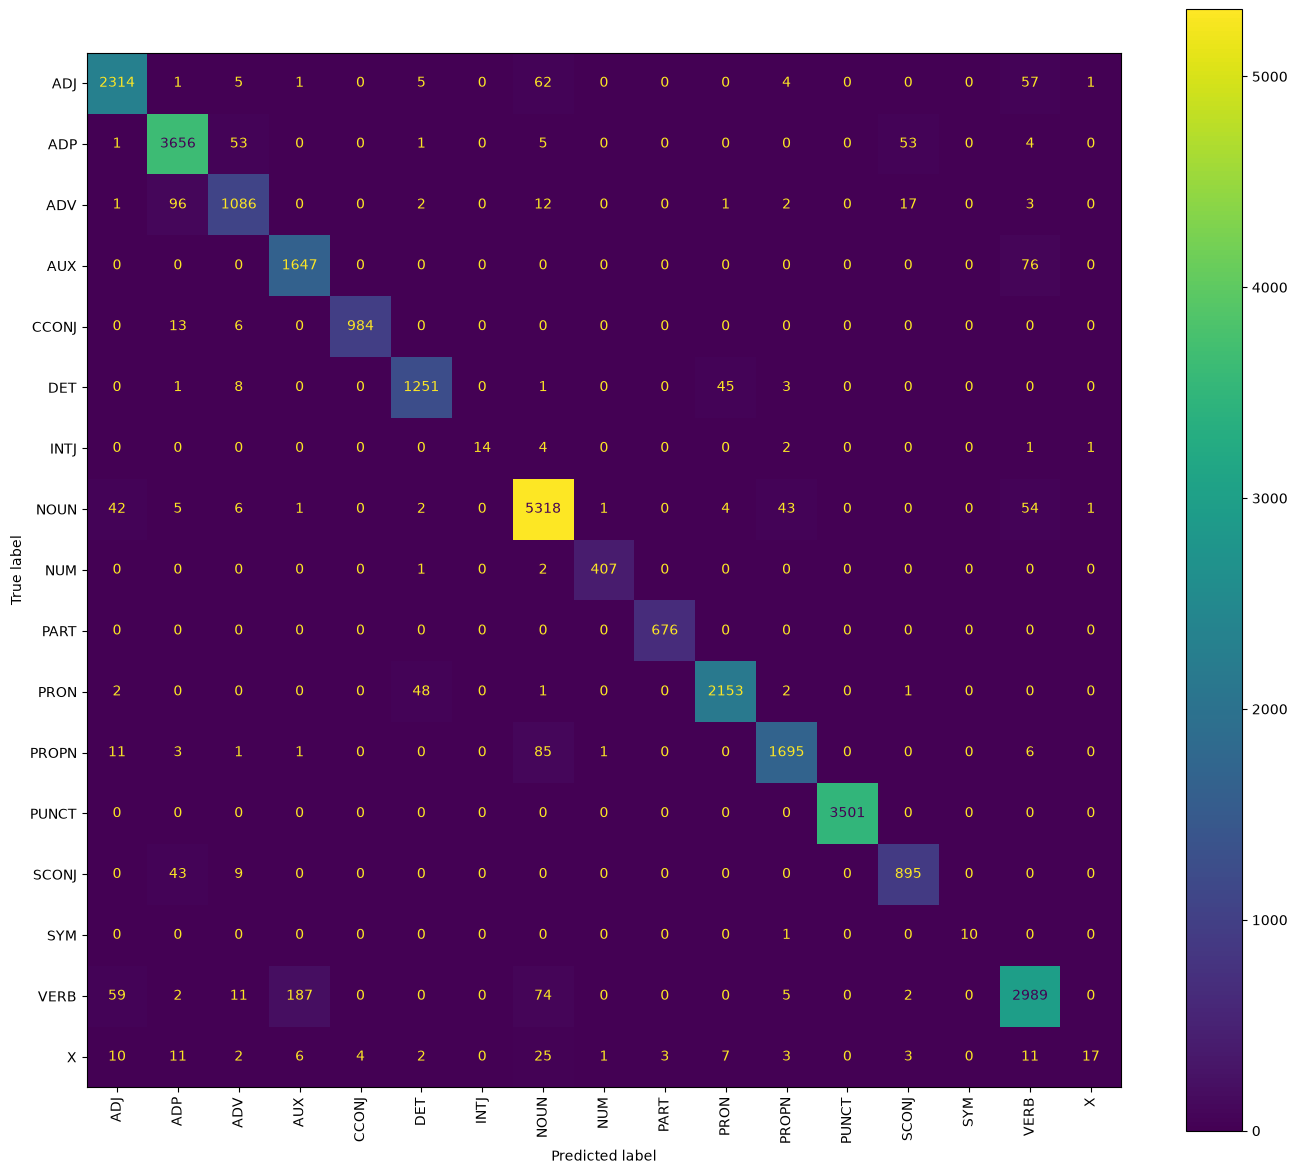

In [57]:
# Task 1.9

best_tagger = GreedyTagger(performance_features_3)
best_tagger.fit(train_data_x, train_data_y)

test_pred = best_tagger.predict(test_data_x)

test_accuracy = tagging_accuracy(test_data_y, test_pred)

print("Test accuracy:", test_accuracy)

#Flatten the list

y_true =[]
y_pred =[]



for sentence in test_data_y:
    y_true.extend(sentence)


for sentence in test_pred:
    y_pred.extend(sentence)

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt



fig, ax = plt.subplots(figsize=(14, 12))
ConfusionMatrixDisplay.from_predictions(y_true,y_pred,ax=ax,xticks_rotation=90)
plt.tight_layout()
plt.show()

#Conclusion
#The test accuracy is about 0.9548488286724955
#Most predictions are correct, as shown by the strong diagonal.
#Some confusion occurs between AUX and VERB, NOUN and PROPN and ADP and SCONJ.

## Part 2 – Span identification with sequence models

In this part, you'll use the same sequence models for a different task: named entity recognition for English.

**Task 2.1** (0.5 point): Write the code to load the train and test data.

In [36]:
def load_ner_data(filename):
    X = []
    Y = []
    sentence = []
    labels = []

    with open(filename, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()

            if line == "":
                if sentence:
                    X.append(sentence)
                    Y.append(labels)
                    sentence = []
                    labels = []
                continue

            parts = line.split()

            if parts[0] == "-DOCSTART-":
                continue

            word = parts[0]
            label = parts[-1]

            sentence.append(word)
            labels.append(label)

    if sentence:
        X.append(sentence)
        Y.append(labels)

    return X, Y


train_nerdata_x, train_nerdata_y = load_ner_data("ner-train.txt")
test_nerdata_x, test_nerdata_y = load_ner_data("ner-test.txt")


print(train_nerdata_x[0])
print(train_nerdata_y[0])

['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.']
['B-ORG', 'O', 'B-MISC', 'O', 'O', 'O', 'B-MISC', 'O', 'O']


**Task 2.2** (0.5 point): Train a greedy tagger with the NER training data. Use any feature set that worked well for POS tagging, but *do not include transition features* for now. Compute the token-level accuracy of the test set, as before.

In [48]:
ner_tagger = GreedyTagger(performance_features_3)

ner_tagger.fit(train_nerdata_x, train_nerdata_y)

pred_ner = ner_tagger.predict(test_nerdata_x)

accuracy_ner = tagging_accuracy(test_nerdata_y, pred_ner)

print("NER accuracy:", accuracy_ner)

#The token-level NER accuracy is about 0.95.


NER accuracy: 0.9537202541186605


**Task 2.3** (1 point): Token-level accuracy is not well adapted to span identification tasks (why?). Instead, we want to compute precision, recall and f-score of the *entities*. Adapt the code below:

In [ ]:
def get_ranges(l):
    """
    Helper procedure for eval_ner.
    You're not expected to change anything here.
    """
    elements = []
    current_element = None
    current_start = None
    for i, ll in enumerate(l):
        if ll == "O":
            if current_element != None:
                elements.append((current_element, current_start, i))
            current_element = None
            current_start = -1
        elif ll[0] == "B":
            if current_element != None:
                elements.append((current_element, current_start, i))
            current_element = ll[2:]
            current_start = i
        elif ll[0] == "I":
            if current_element != ll[2:]:
                elements.append((current_element, current_start, i))
                current_element = ll[2:]
                current_start = i
    return elements


def eval_ner(sys_labels, gold_labels):
    """
    Computes precision, recall and f1-score, using get_ranges() to identify the named entities.
    """
    tp, fp, fn = 0, 0, 0
    for sys_l, gold_l in zip(sys_labels, gold_labels):
        sys_ranges = get_ranges(sys_l)
        gold_ranges = get_ranges(gold_l)
        for r in sys_ranges:   # Count true positives and false positives
            if r in gold_ranges:
                tp += 1
            else:
                fp += 1
    # Count false negatives
        for r in gold_ranges:
            if r not in sys_ranges:
                fn +=1

    recall = tp/(tp+fn)
    prec = tp/(tp+fp)
    f1score = 2*prec*recall / (prec + recall)
   
    return recall, prec, f1score


recall, precision, f1score = eval_ner(pred_ner, test_nerdata_y)

print("Recall:", recall)
print("Precision:", precision)
print("F1-score:", f1score)

#Conclusion

#Recall is 0.7524245196706313, precision is 0.6618380814421374 and F1-score is 0.7042301764000685
#Token-level accuracy is not very good for NER because the whole entity must be correct.
#Precision, recall and F1-score are better for this task.

Recall: 0.7524245196706313
Precision: 0.6618380814421374
F1-score: 0.7042301764000685


Report precision, recall and f1-score of the model trained above.

**Task 2.4** (1 point): Train a new model with transition features and predict the development set labels using `predict_with_history`. How does this change affect the token-level (accuracy) and entity-level (recall, precision, f1-score) metrics?

In [ ]:

# Use the same features as before
def ner_transition_features(sentence, i, history):
    features = performance_features_3(sentence, i, history)

    if i == 0:
        features["prev_tag"] = "<START>"
    else:
        features["prev_tag"] = history[-1]

    return features


ner_tagger_transition = GreedyTagger(ner_transition_features)

ner_tagger_transition.fit(train_nerdata_x, train_nerdata_y)

pred_ner_transition = ner_tagger_transition.predict_with_history(test_nerdata_x)

accuracy_ner_transition = tagging_accuracy( test_nerdata_y, pred_ner_transition )

recall_transition, precision_transition, f1_transition = eval_ner( pred_ner_transition, test_nerdata_y )
print("Without transition:")
print("Accuracy:", accuracy_ner)
print("Recall:", recall)
print("Precision:", precision)
print("F1:", f1score)

print()

print("With transition:")
print("Accuracy:", accuracy_ner_transition)
print("Recall:", recall_transition)
print("Precision:", precision_transition)
print("F1:", f1_transition)

# Conclusion

#I use the same features as before and add the previous tag.
#The accuracy is almost the same.
#Recall, precision and F1-score are better.
#The F1-score increases from about 0.7042301764000685 to 0.7802340702210664
#So the transition feature improves the NER result.

Without transition:
Accuracy: 0.9537202541186605
Recall: 0.7524245196706313
Precision: 0.6618380814421374
F1: 0.7042301764000685

With transition:
Accuracy: 0.9525573382147088
Recall: 0.7685269899359561
Precision: 0.7923033389926429
F1: 0.7802340702210664


**Task 2.5** (2 points): Take some 50 sentences from the test set and display the words, gold tags, and the predicted tags of the two systems. Can you identify error patterns that are typical for the two systems respectively?

In [ ]:

from collections import Counter
# Show the first 50 sentences
for i in range(50):
    print("Sentence", i + 1)
    print("Word\tGold\tSystem1\tSystem2")

    for word, gold, pred1, pred2 in zip( test_nerdata_x[i], test_nerdata_y[i], pred_ner[i], pred_ner_transition[i] ):
        print(word, "\t", gold, "\t", pred1, "\t", pred2)

    print()


# Show only errors

print("Errors:")
print("Word\tGold\tSystem1\tSystem2")

for i in range(50):
    for word, gold, pred1, pred2 in zip( test_nerdata_x[i], test_nerdata_y[i], pred_ner[i], pred_ner_transition[i] ):
        if gold != pred1 or gold != pred2:
            print(word, "\t", gold, "\t", pred1, "\t", pred2)


errors_system1 = 0
errors_system2 = 0

for i in range(50):
    for gold, pred1, pred2 in zip( test_nerdata_y[i], pred_ner[i], pred_ner_transition[i] ):
        if gold != pred1:
            errors_system1 += 1

        if gold != pred2:
            errors_system2 += 1

print("System 1 errors:", errors_system1)
print("System 2 errors:", errors_system2)



errors1 = Counter()
errors2 = Counter()

for i in range(50):
    for gold, pred1, pred2 in zip( test_nerdata_y[i], pred_ner[i], pred_ner_transition[i] ):
        if gold != pred1:
            errors1[(gold, pred1)] += 1

        if gold != pred2:
            errors2[(gold, pred2)] += 1

print("System 1 common errors:")
print(errors1.most_common(10))

print("System 2 common errors:")
print(errors2.most_common(10))


#Conclusion

#System 1 makes 37 errors and System 2 makes 35 errors.
#System 1 often confuses B-PER and I-PER.
#System 2 reduces some boundary errors, but still confuses PER with LOC or ORG.
#Overall, System 2 performs slightly better.

Sentence 1
Word	Gold	System1	System2
SOCCER 	 O 	 O 	 O
- 	 O 	 O 	 O
JAPAN 	 B-LOC 	 B-MISC 	 B-MISC
GET 	 O 	 O 	 O
LUCKY 	 O 	 O 	 O
WIN 	 O 	 O 	 O
, 	 O 	 O 	 O
CHINA 	 B-PER 	 B-ORG 	 B-ORG
IN 	 O 	 O 	 O
SURPRISE 	 O 	 O 	 O
DEFEAT 	 O 	 O 	 O
. 	 O 	 O 	 O

Sentence 2
Word	Gold	System1	System2
Nadim 	 B-PER 	 B-PER 	 B-PER
Ladki 	 I-PER 	 I-PER 	 I-PER

Sentence 3
Word	Gold	System1	System2
AL-AIN 	 B-LOC 	 B-LOC 	 B-LOC
, 	 O 	 O 	 O
United 	 B-LOC 	 B-LOC 	 B-LOC
Arab 	 I-LOC 	 I-LOC 	 I-LOC
Emirates 	 I-LOC 	 I-LOC 	 I-LOC
1996-12-06 	 O 	 O 	 O

Sentence 4
Word	Gold	System1	System2
Japan 	 B-LOC 	 B-LOC 	 B-LOC
began 	 O 	 O 	 O
the 	 O 	 O 	 O
defence 	 O 	 O 	 O
of 	 O 	 O 	 O
their 	 O 	 O 	 O
Asian 	 B-MISC 	 B-MISC 	 B-MISC
Cup 	 I-MISC 	 I-MISC 	 I-MISC
title 	 O 	 O 	 O
with 	 O 	 O 	 O
a 	 O 	 O 	 O
lucky 	 O 	 O 	 O
2-1 	 O 	 O 	 O
win 	 O 	 O 	 O
against 	 O 	 O 	 O
Syria 	 B-LOC 	 B-LOC 	 B-LOC
in 	 O 	 O 	 O
a 	 O 	 O 	 O
Group 	 O 	 O 	 O
C 	 O 	 O 	 O
champions

## Part 3: Text classification with feed-forward neural networks

For this part, we go back to the text classification task used in the first assignment: language identification of Bokmål and Nynorsk.

Instead of manually creating a bag-of-subwords matrix with the BPE-encoded data, we go a simpler route this time and use the `CountVectorizer` class provided by Scikit-Learn. Have a look at the documentation of `CountVectorizer` here: https://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction

With the default parameters, `CountVectorizer` will tokenize the data at whitespaces, remove punctuation signs and convert everything to lowercase. You can play around with the parameters if you wish, but the default settings work decently well. A useful thing to make the vectors smaller is to remove hapaxes, i.e. words that occur only once in the training data. You can achieve this with `min_df=2`.

**Task 3.1** (2 points): Write the code to produce `train_X, train_Y, test_X, test_Y`. Each `*_X` variable should contain a list of vectors produced by `CountVectorizer`. Each `*_Y` variable should contain a list of integers (1 for Nynorsk and 0 for Bokmål).

In [52]:
from sklearn.feature_extraction.text import CountVectorizer

# Read training data
train_text = []
train_Y = []

with open("ndt_train_class.txt", encoding="utf-8") as f: #Use the data from oblig 1
    for line in f: 
        sentence, language = line.strip().split("\t")
        train_text.append(sentence)

        if language == "nno":
            train_Y.append(1)
        else:
            train_Y.append(0)


# Read test data
test_text = []
test_Y = []

with open("ndt_test_class.txt", encoding="utf-8") as f: #use the data from oblig 1 
    for line in f:
        sentence, language = line.strip().split("\t")
        test_text.append(sentence)

        if language == "nno":
            test_Y.append(1)
        else:
            test_Y.append(0)


# Convert text into vectors
vectorizer = CountVectorizer(min_df=2)

train_X = vectorizer.fit_transform(train_text)
test_X = vectorizer.transform(test_text)


print(train_X.shape)
print(len(train_Y))

print(test_X.shape)
print(len(test_Y))

#Conclusion
#The data is ready for training and testing.

(29905, 20629)
29905
(7715, 20629)
7715


**Task 3.2** (1 point): Create a logistic regression classifier, train it on the training set, and predict the labels of the test set. Compute accuracy, precision and recall, as in the previous assignment. How do your results compare with the previous assignment?

In [53]:

from sklearn.metrics import accuracy_score, precision_score, recall_score
classifier = LogisticRegression()
classifier.fit(train_X, train_Y)
predicted_Y = classifier.predict(test_X)


accuracy = accuracy_score(test_Y, predicted_Y)
precision = precision_score(test_Y, predicted_Y)
recall = recall_score(test_Y, predicted_Y)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

#Conclusion.

#The result are quite similar to the previous assignment
#The accuracy is slightly lower
#In the previous assignment, the accuracy was about 94.6%
#compared with about 94.3% in this assignment.

Accuracy: 0.9433570965651329
Precision: 0.9702416028285209
Recall: 0.9074125103334252


In [54]:
# Data from Oblig 1

#Accuracy 0.9464679196370707
#Recall 0.9291815927252687
#Precision 0.95578231292517

**Task 3.3** (1 point): Let us use a simple feed-forward neural network classifier instead of logistic regression, but keep the input feature representation identical. Scikit-Learn provides a simple feed-forward classifier under the name `MLPClassifier`. The most important parameter is `hidden_layer_sizes`, which specifies the number and size of hidden layers. For example, `MLPClassifier(hidden_layer_sizes=(10, 5))` creates a classifier with two hidden layers, the first one with 10 neurons and the second one with 5 neurons. To start, keep the model simple and choose a single hidden layer with 10 neurons. How does this model perform in comparison with logistic regression?

In [30]:
from sklearn.neural_network import MLPClassifier

classifier_2 = MLPClassifier(hidden_layer_sizes=(10,))

classifier_2.fit(train_X, train_Y)

predicted_Y_2 = classifier_2.predict(test_X)

accuracy_2 = accuracy_score(test_Y, predicted_Y_2)
precision_2 = precision_score(test_Y, predicted_Y_2)
recall_2 = recall_score(test_Y, predicted_Y_2)

accuracy_Difference = abs(accuracy - accuracy_2)
precision_Difference = abs(precision - precision_2)
recall_Difference = abs(recall - recall_2)

print("MLP Accuracy:", accuracy_2)
print("MLP Precision:", precision_2)
print("MLP Recall:", recall_2)

print("Accuracy difference =", accuracy_Difference)
print("Precision difference =", precision_Difference)
print("Recall difference =", recall_Difference)

#Conclusion
#The MLP has lower accuracy and precision than logistic regression, 
# while the recall is almost the same. 
# Overall, logistic regression performs slightly better.

MLP Accuracy: 0.932598833441348
MLP Precision: 0.939496748657054
MLP Recall: 0.9156792504822265
Accuracy difference = 0.010758263123784917
Precision difference = 0.030744854171466884
Recall difference = 0.008266740148801355


**Task 3.4** (1 point): Try to improve the results by adding more and/or larger hidden layers. You're not expected to work with more than 50 neurons in total, as this slows down the training process drastically.

In [31]:
# Consider different numbers of neurons

neuron_numbers = [5, 10, 20, 30, 40, 50]

for n in neuron_numbers:

    classifier_3 = MLPClassifier(hidden_layer_sizes=(n,), random_state=4080) #Fix the radom variable for the model

    # train the model
    classifier_3.fit(train_X, train_Y)

    # predict test data 
    predicted_Y_3 = classifier_3.predict(test_X)

    # calculate scores
    accuracy_3 = accuracy_score(test_Y, predicted_Y_3)
    precision_3 = precision_score(test_Y, predicted_Y_3)
    recall_3 = recall_score(test_Y, predicted_Y_3)
 
    print("Number of neurons:", n)
    print("Accuracy:", accuracy_3)
    print("Precision:", precision_3)
    print("Recall:", recall_3)
    print()

#Conclusion
#5 neurons gives the highest accuracy.
#Increasing the number of neurons does not improve the result.
#So more neurons do not always give better performance.
#The result is still slightly lower than logistic regression.

Number of neurons: 5
Accuracy: 0.933246921581335
Precision: 0.9458762886597938
Recall: 0.9101680903830256

Number of neurons: 10
Accuracy: 0.9294880103694102
Precision: 0.9368450863777966
Recall: 0.9115458804078258

Number of neurons: 20
Accuracy: 0.9272845106934543
Precision: 0.9418202764976958
Recall: 0.9010746762193441

Number of neurons: 30
Accuracy: 0.9241736876215165
Precision: 0.9426992437463642
Recall: 0.8930834940755029

Number of neurons: 40
Accuracy: 0.9224886584575502
Precision: 0.9326291749928632
Recall: 0.900248002204464

Number of neurons: 50
Accuracy: 0.9239144523655217
Precision: 0.9429237041351194
Recall: 0.8922568200606228



In [ ]:
# Try more hidden layers, keeping total number of neurons less than equal  50
More_layers_Task_3_4 = [(10, 5), (20, 10), (20, 20), (30, 20)]


for number in More_layers_Task_3_4:
    classifier_4 = MLPClassifier(hidden_layer_sizes=number, random_state=42)
    classifier_4.fit(train_X, train_Y)
    predicted_Y_4 = classifier_4.predict(test_X)

    accuracy_multi = accuracy_score(test_Y, predicted_Y_4)
    precision_multi = precision_score(test_Y, predicted_Y_4)
    recall_multi = recall_score(test_Y, predicted_Y_4)

    print("Accuracy:", accuracy_multi)
    print("Precision:", precision_multi)
    print("Recall:", recall_multi)

#Conclusion

#The hidden layers (20, 10) give the highest accuracy with 0.925599481529488
#But using more hidden layers does not improve the result.
#The single hidden layer with 5 neurons performs better.

Accuracy: 0.9252106286454957
Precision: 0.9387579068430132
Recall: 0.8996968861945439
Accuracy: 0.925599481529488
Precision: 0.9375537095388141
Recall: 0.9019013502342244
Accuracy: 0.9237848347375243
Precision: 0.932574679943101
Recall: 0.9032791402590246
Accuracy: 0.9223590408295528
Precision: 0.9301533219761499
Recall: 0.9027280242491045


Now, let us see if we can improve the input representation. Instead of a bag-of-words model created with `CountVectorizer`, we will obtain document embeddings from a pretrained Norwegian SentenceBert model (in particular, the [base model from the National Library of Norway](https://huggingface.co/NbAiLab/nb-sbert-base)). The following snippet shows how to load and use such a model.

**Task 3.5** (1 point): Produce embeddings for the training and test sets and train a new `MLPClassifier` with these embeddings as input features. Can you further improve the evaluation scores?

Note: Producing the embeddings and training the model will take longer than in previous exercises, around 10 minutes.

In [ ]:
from sentence_transformers import SentenceTransformer

# Uncomment the corresponding line:

# model = SentenceTransformer('NbAiLab/nb-sbert-base') # if you use your own environment

# model = SentenceTransformer("NbAiLab/nb-sbert-base", cache_folder="/fp/projects01/ec403/hf_models") # if you use Fox

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Load SentenceBERT model
model = SentenceTransformer("NbAiLab/nb-sbert-base")

# Produce embeddings
train_embeddings = model.encode(train_text)
test_embeddings = model.encode(test_text)

# Train MLP classifier
classifier_5 = MLPClassifier( hidden_layer_sizes=(10,),random_state=4080)

classifier_5.fit(train_embeddings, train_Y)

# Predict test data
predicted_Y_5 = classifier_5.predict(test_embeddings)

# Calculate scores
accuracy_5 = accuracy_score(test_Y, predicted_Y_5)
precision_5 = precision_score(test_Y, predicted_Y_5)
recall_5 = recall_score(test_Y, predicted_Y_5)

print("Accuracy:", accuracy_5)
print("Precision:", precision_5)
print("Recall:", recall_5)


#Conclusion
#SentenceBERT improves the accuracy and recall.
#The accuracy is about 0.9464679196370707

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Accuracy: 0.9464679196370707
Precision: 0.9469149527515286
Recall: 0.9388261228988702
